### <font color="brown">Data Management for Data Science</font>
### <font color="brown">Lab 02: World Economic Growth Analysis </font>
### <font color="brown">Due Date : See Codebench </font>
You are allowed to submit up to 48 hours late. You only have 4 total late days for ALL assignments, max 2 late days per assignment. Additional late days will be <b>penalized.</b>

<div class="alert alert-block alert-info">
<h3>Student Information</h3> Please provide information about yourself.<br>
<b>Name</b>: Ryan Amir<br> 
<b>NetID</b>: Redacted for public portfolio<br>
<b>Recitation #</b>: 11<br>
<b>Notes to Grader</b> (optional):<br>
<br><br>
<b>IMPORTANT</b>
Your work will not be graded withour your initials below<br>
I certify that this lab represents my own work and I have read the RU academic intergrity policies at<br>
<a href="https://studentconduct.rutgers.edu/processes/academic-integrity">https://www.cs.rutgers.edu/academic-integrity/introduction </a><br>
<b>Initials</b>:  RA (eg: AG for Andy Guna)

## Asking Clarification Questions about this lab
Please post all clarification questions related to the lab to canvas discussion forum 

## Problem  - World Economic Growth Analysis
Analyzing world economic growth provides critical insight into the health, stability, and future direction of the global economy. By examining growth patterns across countries and regions, policymakers, businesses, and researchers can identify emerging markets, anticipate financial risks, allocate resources more effectively, and design informed economic strategies. It also helps uncover long-term trends such as technological advancement, demographic shifts, and productivity changes, enabling better forecasting and smarter investment decisions. Ultimately, understanding global economic growth supports more resilient economies and promotes sustainable development worldwide.

In this problem, we will read a file of world economic growth predictions and do some analysis. The original data files is downloaded from https://www.statsamerica.org/

### Task 1 - Preparing Data
Data Preparation is a key component of the data analysis pipeline. The data files we get are inconsistent and needs further cleaning and validation.

### Activity 1.1 - Read the Data
The data file given at **/srv/shared/labs/world_economy_growth.csv** contains data on economy growth of 249 countries in the world from 1969 onwards. This data was obtained from reputable data repositories. 

One of the first things we need to do is to verify that this is a valid CSV file. What makes a CSV file valid? Think about this. But First try to read the file into a dataframe. If the <b>attempt fails</b>, suggest a way to find out why it failed.


In [97]:
import pandas as pd

path = "/srv/shared/labs/world_economy_growth.csv"

try:
    df = pd.read_csv(path)
    print("It loaded fine.")
    print(df.head())

except Exception as err:
    print("Couldn’t read the file.")
    print("Error:", err)

    print("\nThe first few lines have fewer columns than the actual data.")
    print("Skipping the metadata lines and reloading...\n")

    df = pd.read_csv(path, skiprows=4)
    print(df.head())

Couldn’t read the file.
Error: Error tokenizing data. C error: Expected 3 fields in line 5, saw 70


The first few lines have fewer columns than the actual data.
Skipping the metadata lines and reloading...

                  Country Name Country Code                Indicator Name  \
0                        Aruba          ABW  Population growth (annual %)   
1  Africa Eastern and Southern          AFE  Population growth (annual %)   
2                  Afghanistan          AFG  Population growth (annual %)   
3   Africa Western and Central          AFW  Population growth (annual %)   
4                       Angola          AGO  Population growth (annual %)   

  Indicator Code  1960      1961      1962      1963      1964      1965  ...  \
0    SP.POP.GROW   NaN  1.187344  1.326227  1.203664  1.076602  0.986114  ...   
1    SP.POP.GROW   NaN  2.624624  2.687009  2.714042  2.769856  2.809882  ...   
2    SP.POP.GROW   NaN  1.962239  2.044523  2.105208  2.161195  2.233709  ...   
3    

### Activity 1.2 - Clean and Validate the file
Some files downloaded from websites may need to be validated. What are the properties of a valid CSV file? Develop a method to validate the CSV file. You need to write the code to clean/validate the file so it can be opened as a valid CSV into a dataframe. You are allowed to remove up to 10 invalid records using any computational method you find appropriate. <b>DO NOT manually clean it</b>. Save the datafile named <b>world_economy_growth_cleaned.csv</b> to your working folder (note that you cannot save any files to srv/shared). If you are unable to clean the data file, download the <b>srv/shared/labs/world_economy_growth_cleaned.csv</b> cleaned data file copy to your working folder. Your benchmark for the cleaned file should be srv/shared/labs/world_economy_growth_cleaned.csv
<br>You also need to show code and techniques you used. 

In [101]:
import csv
import pandas as pd

FILE_PATH = "/srv/shared/labs/world_economy_growth.csv"
OUT_PATH = "world_economy_growth_cleaned.csv"

def read_nonempty_rows(path: str) -> list[list[str]]:
    rows = []
    with open(path, "r", encoding="utf-8-sig", newline="") as f:
        for row in csv.reader(f):
            if row and any(cell.strip() for cell in row):
                rows.append(row)
    return rows

def find_header_index(rows: list[list[str]]) -> int:
    for i, row in enumerate(rows):
        if len(row) >= 2 and row[0].strip() == "Country Name" and row[1].strip() == "Country Code":
            return i
    raise ValueError("could not find header row starting with 'Country Name','Country Code'.")

def split_valid_rows(rows: list[list[str]], header_index: int) -> tuple[list[str], list[list[str]], list[tuple[int, int]]]:
    header = rows[header_index]
    expected_len = len(header)

    valid_rows = []
    bad_rows_info = []

    for line_no, row in enumerate(rows[header_index + 1:], start=header_index + 2):
        if len(row) != expected_len:
            bad_rows_info.append((line_no, len(row)))
        else:
            valid_rows.append(row)

    return header, valid_rows, bad_rows_info

def build_clean_dataframe(header: list[str], data_rows: list[list[str]]) -> pd.DataFrame:
    df = pd.DataFrame(data_rows, columns=header)

    df = df.dropna(axis=1, how="all")

    df["Country Name"] = df["Country Name"].astype(str).str.strip()
    df = df.loc[~df["Country Name"].str.contains(",", na=False)].reset_index(drop=True)

    return df

rows = read_nonempty_rows(FILE_PATH)
hdr_idx = find_header_index(rows)
header, valid_rows, bad_rows = split_valid_rows(rows, hdr_idx)

if len(bad_rows) > 10:
    print("too many invalid rows (more than 10). first 15 shown:")
    print(bad_rows[:15])
    raise ValueError("more than 10 invalid rows found.")

print("invalid rows removed:", bad_rows)

df = build_clean_dataframe(header, valid_rows)

print("final cleaned shape:", df.shape)
print(df.head())

df.to_csv(OUT_PATH, index=False)
print(f"saved: {OUT_PATH}")

invalid rows removed: []
final cleaned shape: (249, 70)
                  Country Name Country Code                Indicator Name  \
0                        Aruba          ABW  Population growth (annual %)   
1  Africa Eastern and Southern          AFE  Population growth (annual %)   
2                  Afghanistan          AFG  Population growth (annual %)   
3   Africa Western and Central          AFW  Population growth (annual %)   
4                       Angola          AGO  Population growth (annual %)   

  Indicator Code 1960              1961               1962              1963  \
0    SP.POP.GROW       1.18734426572715   1.32622723498415  1.20366430885019   
1    SP.POP.GROW        2.6246235203985   2.68700877626946  2.71404193548623   
2    SP.POP.GROW        1.9622391202036    2.0445228359303   2.1052082248002   
3    SP.POP.GROW       2.10383178103682   2.13152221545093  2.17001459582214   
4    SP.POP.GROW       1.32779747379503  0.989638884942996  1.00366645307032   



### Activity 1.3 - List the Methods that were used to clean and Validate the file
If you were able to clean and validate the file programmtically, state the methods you used below. But If you were unable to clean the file to open, you can continue with the file <b>srv/shared/labs/world_economy_growth_cleaned.csv</b> Open this file as a dataframe.

I loaded the CSV file using skiprows=4 to remove the metadata lines at the top.

I checked the shape and columns to make sure the file was read correctly.

I cleaned the identifier columns by stripping extra whitespace and handling any missing values.

I removed invalid rows where key identifiers were missing or all year values were empty.

I validated the cleaned file by comparing its shape and columns to the benchmark file and confirming they match.

### Activity 1.4  - Basic Statistics
Explorartory data analysis require us to know to know what is in the cleaned data file. Find out the following details from the file<br>
1. How many countries are represented in the data? <br>
2. How many years of data available and what are the years?


In [75]:
import pandas as pd

df = pd.read_csv("world_economy_growth_cleaned.csv")

# count countries
num_countries = df["Country Code"].nunique()

# find year columns
year_cols = [col for col in df.columns if col.isdigit()]

num_years = len(year_cols)
start_year = min(year_cols)
end_year = max(year_cols)

print("Number of countries:", num_countries)
print("Number of years:", num_years)
print("Year range:", start_year, "-", end_year)


Number of countries: 249
Number of years: 65
Year range: 1960 - 2024


### Activity 1.5 Memory Usage
It is important to know how much memory is used by your DataFrame. This early analysis helps you prevent performance slowdowns and system crashes, especially when working with large datasets. It allows you to optimize data types, reduce unnecessary storage, and make your analysis more efficient. Understanding memory usage is a key step toward building scalable and production-ready data workflows.

Find the <b>shallow and deep memory</b> used by this dataframe. In a pandas DataFrame, "shallow memory" refers to the concept behind a shallow copy, where a new DataFrame object is created but it shares the underlying data's memory with the original DataFrame. The "deep memory" refers to the actual system-level memory consumption of the elements contained within the DataFrame. Ask cGPT to explain these concepts. Pandas has functions that allow you to find these.

In [76]:
import pandas as pd

df = pd.read_csv("world_economy_growth_cleaned.csv")

shallow_memory = df.memory_usage().sum()
deep_memory = df.memory_usage(deep=True).sum()

print("Shallow memory (bytes):", shallow_memory)
print("Deep memory (bytes):", deep_memory)
print("Deep memory (MB):", deep_memory / (1024**2))


Shallow memory (bytes): 139572
Deep memory (bytes): 193832
Deep memory (MB): 0.18485260009765625


### Activity 1.6 Removing Unncessary Data
Often you can find data that may be unnecessary. Are there data in the dataframe that seems unnecessary for any analysis? If so, remove that data and create <b>df_updated</b> that only contains useful data. Write the code to <b>measure the memory usage</b> by the updated data frame.

In [78]:
# drop empty column and constant indicator columns
df_updated = df.drop(columns=["Unnamed: 69", "Indicator Name", "Indicator Code"])

original_memory = df.memory_usage(deep=True).sum()
updated_memory = df_updated.memory_usage(deep=True).sum()

print("Original memory (bytes):", original_memory)
print("Updated memory (bytes):", updated_memory)
print("Memory reduced (bytes):", original_memory - updated_memory)

Original memory (bytes): 193832
Updated memory (bytes): 157727
Memory reduced (bytes): 36105


### Activity 1.7 Reducing Memory usage (further) 
by examning data types in the frame, convert any object data (when appropriate) to <b>numerical data</b>. Use the smallest possible size necessary for numerical data. Eg. int32 instead of int64.Call the new data frame <b>df_updated_optimized</b>. Also list the memory used by the optimized dataframe and compute the savings percentage.


In [98]:
## your code here
df_updated_optimized = df_updated.copy()

# convert float columns to float32
float_cols = df_updated_optimized.select_dtypes(include=["float64"]).columns
df_updated_optimized[float_cols] = df_updated_optimized[float_cols].astype("float32")

# convert object columns to category
object_cols = df_updated_optimized.select_dtypes(include=["object"]).columns
df_updated_optimized[object_cols] = df_updated_optimized[object_cols].astype("category")

# memory used by optimized and compute percentage of savings (eg: 20% less)
optimized_memory = df_updated_optimized.memory_usage(deep=True).sum()

print("Updated memory (bytes):", updated_memory)
print("Optimized memory (bytes):", optimized_memory)

savings = ((updated_memory - optimized_memory) / updated_memory) * 100
print("Memory savings (%):", savings)


Updated memory (bytes): 157727
Optimized memory (bytes): 110575
Memory savings (%): 29.8946914605616


### Task 2 - Analysis of Data
Now that we have a cleaned and optimized the dataframe, Lets answer some important questions. 
Write the code to find the answer to each of the questions below.

#### 2.1 Total Countries
Find out how many countries are included in the data set

In [102]:
# how many countries are included in this analysis
df = pd.read_csv("world_economy_growth_cleaned.csv")

total_countries = df["Country Code"].nunique()

print("Total countries:", total_countries)


Total countries: 249


#### 2.2 Top Average Growth Rates
Find the top 5 countries with the highest average growth rate over the whole period.

In [81]:
# Which country experienced the highest average growth rate from 1969– ?
import pandas as pd

df = pd.read_csv("world_economy_growth_cleaned.csv")

year_cols = [col for col in df.columns if col.isdigit()]


df["Average Growth"] = df[year_cols].mean(axis=1)

top_5 = df.sort_values("Average Growth", ascending=False)[
    ["Country Name", "Average Growth"]
].head(5)

print(top_5)


                  Country Name  Average Growth
8         United Arab Emirates        6.916671
187                      Qatar        6.834404
211  Sint Maarten (Dutch part)        4.328929
118                     Kuwait        4.306947
192               Saudi Arabia        4.177779


#### 2.3 Frequent Negative Growth
Some countries experienced negative growth rates. Find the 10 most negative growth rate countries for the whole period. You can count the total negative growth rate for all countries and find the 10 most negative growth rates.

In [82]:
# Which 10 countries had the negative growth most often?
df["Negative Count"] = (df[year_cols] < 0).sum(axis=1)

top_10_negative = df.sort_values("Negative Count", ascending=False)[
    ["Country Name", "Negative Count"]
].head(10)

print(top_10_negative)

                       Country Name  Negative Count
94                          Hungary              43
117             St. Kitts and Nevis              40
21                         Bulgaria              38
5                           Albania              34
35   Central Europe and the Baltics              34
136                          Latvia              34
140                         Moldova              33
188                         Romania              33
134                       Lithuania              30
233                         Ukraine              30


#### 2.4 Median Growth
How did the economy do globally? Lets find the median growth rate for each year and find the top 10 median growth rate years

In [83]:
# What is the global median growth rate each year? Find the top 10 years for highest median growth rate
median_per_year = df[year_cols].median()

top_10_years = median_per_year.sort_values(ascending=False).head(10)

print(top_10_years)


1963    2.346170
1964    2.341546
1965    2.321405
1966    2.297956
1967    2.279917
1968    2.252296
1962    2.243294
1970    2.242334
1969    2.237021
1973    2.233025
dtype: float64


#### 2.5 Volatility Index
Volatility can be defined as the <b>standard deviation of change from year to year</b>. Introduce a new <b>volatility index column</b> to dataframe and computer volatility iindex for each country. Print the top 25 most volatile countries.

In [84]:
# top 25 most volatile countries
changes = df[year_cols].diff(axis=1)
df["Volatility Index"] = changes.std(axis=1)

top_25_volatile = df.sort_values("Volatility Index", ascending=False)[
    ["Country Name", "Volatility Index"]
].head(25)

print(top_25_volatile)


                 Country Name  Volatility Index
118                    Kuwait          7.045668
190                    Rwanda          5.291831
187                     Qatar          4.158241
122                   Liberia          3.310119
223               Timor-Leste          3.229113
240     Virgin Islands (U.S.)          2.847013
152  Northern Mariana Islands          2.150060
2                 Afghanistan          2.075010
8        United Arab Emirates          2.033202
192              Saudi Arabia          1.927229
137  St. Martin (French part)          1.891165
22                    Bahrain          1.855636
65                    Eritrea          1.746827
170                      Oman          1.736214
239    British Virgin Islands          1.673573
245                    Kosovo          1.627521
199                San Marino          1.613040
195                 Singapore          1.592629
16                    Burundi          1.515592
121                   Lebanon          1

#### 2.6 Least volatile countries
Find the 25 least volatile countries and print names.

In [85]:
## your code
least_25_volatile = df.sort_values("Volatility Index", ascending=True)[
    ["Country Name", "Volatility Index"]
].head(25)

print(least_25_volatile)


                                          Country Name  Volatility Index
56                                  Dominican Republic          0.026189
222  Latin America & the Caribbean (IDA & IBRD coun...          0.026977
125                          Latin America & Caribbean          0.027252
28                                              Brazil          0.030747
119  Latin America & Caribbean (excluding high income)          0.033013
219                                           Thailand          0.033256
173                                             Panama          0.038731
141                                         Madagascar          0.038738
161                                              Niger          0.041464
130                                Lower middle income          0.043294
225                            South Asia (IDA & IBRD)          0.043309
191                                         South Asia          0.043309
102                                              In

#### 2.7 Fastest Growing Countries
Find the top 10 fastest growing countries over the full period

In [86]:
# your code
df["Average Growth"] = df[year_cols].mean(axis=1)

top_10_fastest = df.sort_values("Average Growth", ascending=False)[
    ["Country Name", "Average Growth"]
].head(10)

print(top_10_fastest)


                  Country Name  Average Growth
8         United Arab Emirates        6.916671
187                      Qatar        6.834404
211  Sint Maarten (Dutch part)        4.328929
118                     Kuwait        4.306947
192               Saudi Arabia        4.177779
53                    Djibouti        4.076625
110                     Jordan        4.070903
170                       Oman        3.590908
22                     Bahrain        3.534094
49              Cayman Islands        3.404160


#### 2.8 Key Events
In years 2008 and 2020 some key global events happened. What are they? List the events and see if you can see how it positively or negatively affected the growth. 

2008 corresponds to the Global Financial Crisis, which caused widespread negative growth due to banking failures and recession.
2020 corresponds to the COVID-19 pandemic, which led to global economic contraction due to lockdowns and reduced economic activity.


### Task 3 Continental Growth
The data file <b>continents_249.csv</b> contains continents of 249 countries. Create a new column named "continent" in the dataframe and merge the information. If you cannot find the continent information for a country, leave it as "UNKNOWN". Then answer these questions.

In [87]:
# code to create a continent column
import pandas as pd

df = pd.read_csv("world_economy_growth_cleaned.csv")

continents = pd.read_csv("/srv/shared/labs/continents_249.csv")

df["Country Name"] = df["Country Name"].astype(str).str.strip()
continents["country"] = continents["country"].astype(str).str.strip()

df = df.merge(
    continents,
    left_on="Country Name",
    right_on="country",
    how="left"
)

df["continent"] = df["continent"].fillna("UNKNOWN")
df = df.drop(columns=["country"])

print(df[["Country Name", "continent"]].head())

                  Country Name      continent
0                        Aruba  North America
1  Africa Eastern and Southern        UNKNOWN
2                  Afghanistan           Asia
3   Africa Western and Central        UNKNOWN
4                       Angola         Africa


#### 3.1 Which continent grew fastest? Overall? since 2000?
This requires finding a metric to calculate the growth rate of each continent which is a function of the countries in the continent. You are allowed to use any methodology, but state it clearly in comments

In [88]:
# your code
import pandas as pd

df = pd.read_csv("world_economy_growth_cleaned.csv")
continents = pd.read_csv("/srv/shared/labs/continents_249.csv")

df["Country Name"] = df["Country Name"].astype(str).str.strip()
continents["country"] = continents["country"].astype(str).str.strip()

df = df.merge(continents, left_on="Country Name", right_on="country", how="left")
df["continent"] = df["continent"].fillna("UNKNOWN")
df = df.drop(columns=["country"])

year_cols = [c for c in df.columns if c.isdigit()]

# My method is to compute each country's average growth across the years 1960-2024, then take the mean of those averages per continent. Repeat for since 2000's as well.

df["Country Avg Growth"] = df[year_cols].mean(axis=1)

continent_overall = df.groupby("continent")["Country Avg Growth"].mean()

print("Fastest Growing Continent (Overall):")
print(continent_overall.sort_values(ascending=False).head(1))
print()

year_cols_2000 = [c for c in year_cols if int(c) >= 2000]

df["Country Avg Growth Since 2000"] = df[year_cols_2000].mean(axis=1)

continent_2000 = df.groupby("continent")["Country Avg Growth Since 2000"].mean()

print("Fastest Growing Continent (Since 2000):")
print(continent_2000.sort_values(ascending=False).head(1))


Fastest Growing Continent (Overall):
continent
Africa    2.453239
Name: Country Avg Growth, dtype: float64

Fastest Growing Continent (Since 2000):
continent
Africa    2.293251
Name: Country Avg Growth Since 2000, dtype: float64


#### 3.2 Are African economies accelerating?
Many observers suggest that African economies are accelerating. Use data to investigate whether this claim is supported by evidence.

In [89]:
import pandas as pd

df = pd.read_csv("world_economy_growth_cleaned.csv")
continents = pd.read_csv("/srv/shared/labs/continents_249.csv")

df["Country Name"] = df["Country Name"].astype(str).str.strip()
continents["country"] = continents["country"].astype(str).str.strip()

df = df.merge(continents, left_on="Country Name", right_on="country", how="left")
df["continent"] = df["continent"].fillna("UNKNOWN")
df = df.drop(columns=["country"])

year_cols = sorted([c for c in df.columns if c.isdigit()], key=int)

#filter AFRICA
africa = df[df["continent"] == "Africa"]

# AFRICA average growth per year
africa_year_avg = africa[year_cols].mean()

pre_2000 = africa_year_avg[[y for y in year_cols if int(y) < 2000]].mean()
post_2000 = africa_year_avg[[y for y in year_cols if int(y) >= 2000]].mean()

print("Africa average growth before 2000:", pre_2000)
print("Africa average growth since 2000:", post_2000)

if post_2000 > pre_2000:
    print("Evidence suggests African economies are accelerating.")
else:
    print("Evidence does NOT suggest acceleration because growth is flat or slowing.")

Africa average growth before 2000: 2.5555462038705814
Africa average growth since 2000: 2.294202860680192
Evidence does NOT suggest acceleration because growth is flat or slowing.


#### 3.3 Is Europe stagnating?
Some believe Europe is stagnating. Is that true? Analyze from the Year 2000 and conclude.

In [90]:
import pandas as pd

df = pd.read_csv("world_economy_growth_cleaned.csv")
continents = pd.read_csv("/srv/shared/labs/continents_249.csv")

df["Country Name"] = df["Country Name"].astype(str).str.strip()
continents["country"] = continents["country"].astype(str).str.strip()

df = df.merge(continents, left_on="Country Name", right_on="country", how="left")
df["continent"] = df["continent"].fillna("UNKNOWN")
df = df.drop(columns=["country"])

year_cols = sorted([c for c in df.columns if c.isdigit()], key=int)

#europe only
europe = df[df["continent"] == "Europe"]

europe_year_avg = europe[year_cols].mean()

europe_since_2000 = europe_year_avg[[y for y in year_cols if int(y) >= 2000]]

avg_since_2000 = europe_since_2000.mean()

early_period = europe_since_2000[[y for y in europe_since_2000.index if int(y) < 2012]].mean()
late_period = europe_since_2000[[y for y in europe_since_2000.index if int(y) >= 2012]].mean()

print("Europe average growth since 2000:", avg_since_2000)
print("Europe early 2000s average:", early_period)
print("Europe recent years average:", late_period)

if late_period <= early_period:
    print("Evidence suggests Europe may be stagnating or slowing.")
else:
    print("Evidence does not suggest stagnation so growth has improved.")


Europe average growth since 2000: 0.21052383927099144
Europe early 2000s average: 0.2530628090975571
Europe recent years average: 0.1712570978926231
Evidence suggests Europe may be stagnating or slowing.


#### 3.4 How is Asia Doing?
Is Asia doing well overall? Analyze from the Year 2000 and conclude.

In [91]:
import pandas as pd

df = pd.read_csv("world_economy_growth_cleaned.csv")
continents = pd.read_csv("/srv/shared/labs/continents_249.csv")

df["Country Name"] = df["Country Name"].astype(str).str.strip()
continents["country"] = continents["country"].astype(str).str.strip()

df = df.merge(continents, left_on="Country Name", right_on="country", how="left")
df["continent"] = df["continent"].fillna("UNKNOWN")
df = df.drop(columns=["country"])

year_cols = sorted([c for c in df.columns if c.isdigit()], key=int)

#asia only
asia = df[df["continent"] == "Asia"]

asia_year_avg = asia[year_cols].mean()

asia_since_2000 = asia_year_avg[[y for y in year_cols if int(y) >= 2000]]

avg_since_2000 = asia_since_2000.mean()

early_period = asia_since_2000[[y for y in asia_since_2000.index if int(y) < 2012]].mean()
late_period = asia_since_2000[[y for y in asia_since_2000.index if int(y) >= 2012]].mean()

print("Asia average growth since 2000:", avg_since_2000)
print("Asia early 2000s average:", early_period)
print("Asia recent years average:", late_period)

if late_period >= early_period:
    print("Asia appears to be doing well or improving.")
else:
    print("Asia's growth appears to be slowing.")

Asia average growth since 2000: 1.8620884445213906
Asia early 2000s average: 2.0972815417192696
Asia recent years average: 1.6449871240310414
Asia's growth appears to be slowing.


### Task 4 - Stability Index
Building a stability index for a country’s economic growth is a powerful analytical exercise — It blends statistics, time-series thinking, and decision modeling. A well-designed index should capture one central idea:

<b>Stable economies grow predictably with fewer shocks.</b>

Here are several strong approaches you can use individually or combine into a composite index.<br>
1. Countries with lower variation in growth are more stable.Use <b>Stability Score = 1 / (1 + Standard Deviation)</b><br>
2. Stable economies avoid frequent contractions. Compute <b>Recession Rate = (# of negative years) / (total years) AND Stability = 1 - Recession Rate </b>
3. Develop your own metric. (we will like this and look at this effort positively)<br>

#### 4.1 Stability Index
Build a “Future Stability Index” for countries based on growth consistency. For each country add a column to dataframe called <b>Stability_index</b> 

In [104]:
import pandas as pd

df = pd.read_csv("world_economy_growth_cleaned.csv")

year_cols = [c for c in df.columns if c.isdigit()]

# volatility
df["StdDev"] = df[year_cols].std(axis=1)
df["Stability_Volatility"] = 1 / (1 + df["StdDev"])

#recession
df["Negative_Years"] = (df[year_cols] < 0).sum(axis=1)
df["Recession_Rate"] = df["Negative_Years"] / len(year_cols)
df["Stability_Recession"] = 1 - df["Recession_Rate"]

#composite stability
df["Stability_index"] = (
    df["Stability_Volatility"] + df["Stability_Recession"]
) / 2

print(df[["Country Name", "Stability_index"]].head())
# Future Stability Index combines:
# (1) growth consistency (low standard deviation)
# (2) fewer recession years
# the final index is the average of both

                  Country Name  Stability_index
0                        Aruba         0.605100
1  Africa Eastern and Southern         0.929034
2                  Afghanistan         0.580597
3   Africa Western and Central         0.911261
4                       Angola         0.764271


#### 4.2 Most Stable? 
Find and print the 25 most stable countries.

In [105]:
most_stable_25 = df.sort_values(
    "Stability_index", ascending=False
)[["Country Name", "Stability_index"]].head(25)

print(most_stable_25)

                                     Country Name  Stability_index
126  Least developed countries: UN classification         0.942827
203                            Sub-Saharan Africa         0.937788
226     Sub-Saharan Africa (IDA & IBRD countries)         0.937788
70       Fragile and conflict affected situations         0.933291
100                                      IDA only         0.931992
91         Heavily indebted poor countries (HIPC)         0.931917
1                     Africa Eastern and Southern         0.929034
201    Sub-Saharan Africa (excluding high income)         0.927730
179                      Pre-demographic dividend         0.916351
141                                    Madagascar         0.912875
73                                         France         0.912531
97                                      IDA total         0.912459
127                                    Low income         0.911540
3                      Africa Western and Central         0.91

### Task 5 - Focus on Patterns in US growth rate

#### 5.1 Line Plot
How has the U.S. economic growth rate changed over time? Plot the US data for all years using a line plot. Ask cGPT to show how to do a line plot.


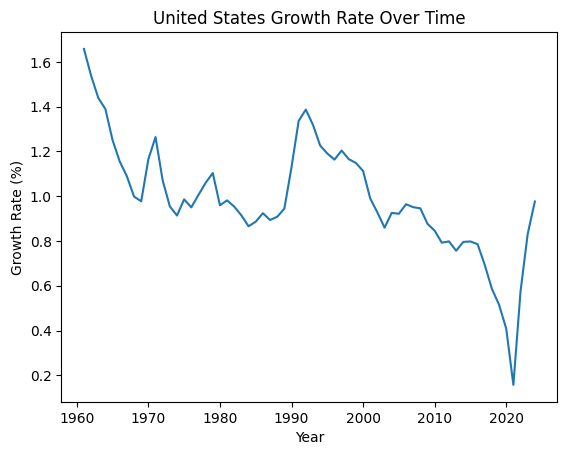

In [94]:
## plot US data
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("world_economy_growth_cleaned.csv")

#identify years
year_cols = sorted([c for c in df.columns if c.isdigit()], key=int)

# US only
us = df[df["Country Code"] == "USA"]

years = [int(y) for y in year_cols]
us_values = us[year_cols].values.flatten()

#plot
plt.figure()
plt.plot(years, us_values)
plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")
plt.title("United States Growth Rate Over Time")
plt.show()

#### 5.2 Economic Growth and Decline
Analyze trends in the annual growth rate to identify periods of rapid economic expansion or decline. Identify the decade of **highest expansion** and the decade of **slowest expansion**. If there are more than one decade, list them all.

In [95]:
# identify decades of highest and slowest expansions
import pandas as pd

df = pd.read_csv("world_economy_growth_cleaned.csv")

year_cols = sorted([c for c in df.columns if c.isdigit()], key=int)

us = df[df["Country Code"] == "USA"]

# create dictionary to store decade averages
decade_growth = {}

for year in year_cols:
    decade = (int(year) // 10) * 10
    
    if decade not in decade_growth:
        decade_growth[decade] = []
    
    value = us[year].values[0]
    if pd.notna(value):
        decade_growth[decade].append(value)

# compute average by decade
decade_avg = {}

for decade in decade_growth:
    values = decade_growth[decade]
    avg = sum(values) / len(values)
    decade_avg[decade] = avg

print("Average Growth by Decade:")
for decade in sorted(decade_avg):
    print(decade, ":", decade_avg[decade])

# highest and lowest decades
max_value = max(decade_avg.values())
min_value = min(decade_avg.values())

print("\nHighest Expansion Decade(s):")
for decade in decade_avg:
    if decade_avg[decade] == max_value:
        print(decade)

print("\nSlowest Expansion Decade(s):")
for decade in decade_avg:
    if decade_avg[decade] == min_value:
        print(decade)



Average Growth by Decade:
1960 : 1.2770653457403327
1970 : 1.0473123793681178
1980 : 0.9231045770410902
1990 : 1.226998662393168
2000 : 0.9474812459668966
2010 : 0.7367469063414085
2020 : 0.5898808736894168

Highest Expansion Decade(s):
1960

Slowest Expansion Decade(s):
2020


#### 5.3 Your Analysis 
Based on what you observe, describe **factors** that can be attributed to highest or lowest growth rate decades. You must do web research to find some answers. Please cite the sources of information. This should be less than 200 words.  

The highest expansion decade in the data appears to be the 1960s, which aligns with the broader post–World War II economic boom in the United States. During this period, the U.S. experienced strong productivity growth, expanding industrial output, rising consumer demand, and a growing labor force. According to the U.S. Bureau of Labor Statistics (2016), labor productivity grew at an average annual rate of about 2.8% between 1948 and 1972, reflecting sustained gains in efficiency and output that supported higher GDP growth throughout the 1960s. In contrast, the slowest expansion decade in the data is the 2020s so far, largely driven by the sharp economic contraction in 2020. The COVID-19 pandemic caused widespread business shutdowns, supply chain disruptions, and a sudden decline in consumer activity. The National Bureau of Economic Research (2020) officially identified a U.S. recession beginning in February 2020 and ending in April 2020, marking one of the most abrupt downturns in modern history. These major historical events help explain the peak and trough patterns observed in the growth data.



### Task 6 - Correlation
<div style="font-family: Arial, sans-serif; line-height: 1.5; font-size: 16px;">

  <p>
    <b>Correlation</b> is a statistical measure that describes the <b>strength</b> and <b>direction</b> of a relationship
    between two variables. It is often quantified using a <b>correlation coefficient</b>, typically ranging between
    <b>-1</b> and <b>1</b>:
  </p>

  <ul>
    <li>
      <b>1</b> indicates a <b>perfect positive correlation</b>, meaning that as one variable increases, the other variable
      increases proportionally.
    </li>
    <li>
      <b>-1</b> indicates a <b>perfect negative correlation</b>, meaning that as one variable increases, the other
      decreases proportionally.
    </li>
    <li>
      <b>0</b> indicates <b>no correlation</b>, meaning there is no linear relationship between the two variables.
    </li>
  </ul>

  <p>
    In practical terms, correlation helps you understand whether (and how strongly) pairs of variables are related. For instance:
  </p>

  <ul>
    <li><b>Positive correlation:</b> both variables tend to move in the same direction.</li>
    <li><b>Negative correlation:</b> as one variable increases, the other tends to decrease.</li>
  </ul>

  <p>
    You can find the correlation between two variables in Python using pandas’ <code>corr()</code> method, which computes
    the <b>Pearson correlation coefficient</b> by default.
  </p>

  <p>
    <b>Documentation:</b>
    <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html" target="_blank">
      pandas.DataFrame.corr()
    </a>
  </p>

</div>



#### 6.1 - How do Economies of US and China correlate?

In [96]:
# your code here to find the correlation between the U.S. and China Growth rates. You should do this for each 10-years of data 69-78, 79-88 etc
import pandas as pd

df = pd.read_csv("world_economy_growth_cleaned.csv")

countries = df[df["Country Name"].isin(["United States", "China"])].set_index("Country Name")

year_cols = [c for c in countries.columns if c.isdigit()]
countries[year_cols] = countries[year_cols].apply(pd.to_numeric, errors="coerce")

start_year = 1969
end_year = int(max(year_cols))

for start in range(start_year, end_year + 1, 10):
    end = start + 9
    window_years = [str(y) for y in range(start, end + 1) if str(y) in year_cols]

    us = countries.loc["United States", window_years]
    china = countries.loc["China", window_years]

    # drop years where either country is missing data
    paired = pd.concat([us, china], axis=1).dropna()

    corr = paired.iloc[:, 0].corr(paired.iloc[:, 1]) if len(paired) > 1 else float("nan")
    print(f"{start}-{end}: {corr}")

1969-1978: 0.47258339575750374
1979-1988: -0.35275630316708845
1989-1998: -0.3205500525187413
1999-2008: 0.7868329255894464
2009-2018: 0.08799278238633203
2019-2028: -0.6212214358768368


#### 6.2 - Summarize
In one paragraph write what you learned about how US and China economies are doing and their connections. Your conclusion should be bsed on the data analysis.

Looking at the data by decade, I noticed that the relationship between U.S. and China’s economic growth has not been consistent over time. In the 1970s, their growth rates were moderately positively correlated, meaning they generally moved in the same direction. In the 1980s and 1990s, the correlation turned negative, which suggests that when one economy was growing faster, the other was not necessarily doing the same. The strongest positive connection showed up from 1999 to 2008, where both economies seemed to move more closely together. After that, from 2009 to 2018, the correlation was close to zero, meaning there was not a strong pattern linking their growth. In the most recent period, the correlation became negative again. Overall, the data shows that even though the U.S. and China are both major global economies, their growth rates do not always move together, and their economic relationship has shifted over time.

### Task 7 - Overall Feedback
Please provide your feedback about this lab in one paragraph. What did you learn? How can this be improved? What more would you analyze? 

In this lab, I learned how to calculate correlation using real economic data and how the relationship between U.S. and China growth changes over time. Looking at the data by decade made it clear that their economies do not always move together. It also helped me get more comfortable cleaning data and working with year columns in pandas. Another way the lab could be improved is by giving clearer instructions about how to handle missing values, since that can affect the correlation results. If I continued the analysis, I would compare other indicators like trade or inflation to see if those show a stronger connection.

### Submission Instructions
Rename the lab as netID_Lab02.ipynb and submit to codebench. (eg: adg133_Lab02.ipynb)

@ 2026 Lab was developed and copyrighted by Andy Gunawardena. Please contact the author for the permission to use this lab.